In [2]:
# Yet to be implemented.
import talib
import bt # Backtesting library for backtesting trading strategies. 
# Trading signals 
# 1. SMA, EMA signals 
# 2. Trend following strategies :
#    2.1 Bet the price will continue in the same direction as the trend. 
#        Buy when price crosses above SMA/EMA and sell when price crosses below SMA/EMA.  
#        Use ADX to confirm the trend. 
#    2.2 Mean reversion strategies : 
#        Bet the price will revert to the mean.  
#        Use RSI, BBands to confirm the mean reversion. 
#        FI: RSI < 30 and BBands < 30.  => Buy. RSI > 70 and BBands > 70.  => Sell.  Otherwise, do nothing. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.graph_objects as go 
import sys
sys.path.insert(0, r"C:\Uni\Year 3\flash-crash-sentinel\python_components")

In [3]:
df = pd.read_csv(r"C:\Uni\Year 3\flash-crash-sentinel\python_components\historicalData\NVDA.csv")
df.set_index("timestamp", inplace=True)
df.index = pd.to_datetime(df.index)
print(df.head())
print(df.info())
print(df.describe())
fig = go.Figure(go.Candlestick(
    x=df.index,
    open=df["open"],
    high=df["high"],
    low=df["low"],
    close=df["close"],
    name="NVDA"
))
fig.show()


                    event_type ticker       open       high        low  \
timestamp                                                                
2023-11-29 09:30:00       TICK   NVDA  48.379002  48.762001  48.123001   
2023-11-29 10:30:00       TICK   NVDA  48.324928  48.549999  47.941700   
2023-11-29 11:30:00       TICK   NVDA  47.974998  48.223999  47.860001   
2023-11-29 12:30:00       TICK   NVDA  48.217010  48.266991  48.067001   
2023-11-29 13:30:00       TICK   NVDA  48.194500  48.234001  48.026001   

                         close      volume      VPIN  vol  regime  \
timestamp                                                           
2023-11-29 09:30:00  48.325001  12452902.0  0.055752  0.0       0   
2023-11-29 10:30:00  47.972500   5784194.0  0.349299  0.0       0   
2023-11-29 11:30:00  48.220001   3871884.0  0.249936  0.0       0   
2023-11-29 12:30:00  48.194500   2688636.0  0.023339  0.0       0   
2023-11-29 13:30:00  48.151001   2320840.0  0.045098  0.0       0  

In [4]:
#helper function
def yang_zhang_volatility(df: pd.DataFrame) -> float:
    """
    Compute Yang-Zhang volatility over a window.
    Expects columns: open, high, low, close
    """
    n = len(df)
    if n < 2:
        return 0.0

    o = df["open"].values
    h = df["high"].values
    l = df["low"].values
    c = df["close"].values

    # k constant
    k = 0.34 / (1.34 + (n + 1) / (n - 1))

    # Overnight jump
    log_oj = np.log(o[1:] / c[:-1])
    var_oj = np.nanvar(log_oj, ddof=1) if len(log_oj) > 1 else 0.0

    # Open-to-close
    log_oc = np.log(c / o)
    var_oc = np.nanvar(log_oc, ddof=1) if len(log_oc) > 1 else 0.0

    # Rogers–Satchell
    u = np.log(h / o)
    d = np.log(l / o)
    rsc = u * (u - np.log(c / o)) + d * (d - np.log(c / o))
    var_rs = np.nanmean(rsc)

    sigma_sq = var_oj + k * var_oc + (1 - k) * var_rs

    return np.sqrt(sigma_sq) if sigma_sq > 0 else 0.0


In [9]:
# Feature Engineering Helper Function (for multi-asset support)
from services.vol_service import VolatilityService

def build_features(df_ticker: pd.DataFrame, ticker_name: str) -> pd.DataFrame:
    """Build technical indicators for a single ticker."""
    df_feat = df_ticker.copy()
    df_feat["5d_close_pct"] = df_feat["close"].pct_change(5)
    
    for window in [5, 14, 21]: 
        # Relative Strength Index (RSI) for momentum 
        df_feat[f"rsi_{window}"] = talib.RSI(df_feat["close"], timeperiod=window)
        # Simple Moving Average (SMA) for trend 
        df_feat[f"sma_{window}"] = talib.SMA(df_feat["close"], timeperiod=window)
        # Exponential Moving Average (EMA) for trend 
        df_feat[f"ema_{window}"] = talib.EMA(df_feat["close"], timeperiod=window)
        # Bollinger Bands (BBands) for volatility 
        df_feat[f"bbands_{window}_upper"], df_feat[f"bbands_{window}_middle"], df_feat[f"bbands_{window}_lower"] = talib.BBANDS(df_feat["close"], timeperiod=window, nbdevup=2, nbdevdn=2)
        # Average Directional Index (ADX) for trend 
        df_feat[f"adx_{window}"] = talib.ADX(df_feat["high"], df_feat["low"], df_feat["close"], timeperiod=window)

        # Yang–Zhang volatility (reuse the project implementation for consistency)
        _yz = VolatilityService(csv_path="")
        ohlc = df_feat[["open", "high", "low", "close"]].astype(float)

        yz_vals = [float("nan")] * len(ohlc)
        for i in range(window - 1, len(ohlc)):
            yz_vals[i] = _yz._calculate_yang_zhang(ohlc.iloc[i - window + 1 : i + 1])

        df_feat[f"yang_zhang_{window}"] = pd.Series(yz_vals, index=df_feat.index)
    
    return df_feat

# Load and build features for single ticker (for backward compatibility)
df = build_features(df, "NVDA")
print("Single ticker (NVDA) features built")
print(df.head())
print(df.info())

Single ticker (NVDA) features built
                    event_type ticker       open       high        low  \
timestamp                                                                
2023-11-29 09:30:00       TICK   NVDA  48.379002  48.762001  48.123001   
2023-11-29 10:30:00       TICK   NVDA  48.324928  48.549999  47.941700   
2023-11-29 11:30:00       TICK   NVDA  47.974998  48.223999  47.860001   
2023-11-29 12:30:00       TICK   NVDA  48.217010  48.266991  48.067001   
2023-11-29 13:30:00       TICK   NVDA  48.194500  48.234001  48.026001   

                         close      volume      VPIN  vol  regime  ...  \
timestamp                                                          ...   
2023-11-29 09:30:00  48.325001  12452902.0  0.055752  0.0       0  ...   
2023-11-29 10:30:00  47.972500   5784194.0  0.349299  0.0       0  ...   
2023-11-29 11:30:00  48.220001   3871884.0  0.249936  0.0       0  ...   
2023-11-29 12:30:00  48.194500   2688636.0  0.023339  0.0       0  ...   
2

✓ Sentiment data loaded: 703 days
Trades: entries=74, exits=74, stop-losses=0 (0.0% of exits)
Train/Test split timestamp: 2025-04-25 15:30:00 (70/30)
Approx trades: entries=74, exits=74; cost_rate=0.0015


100%|██████████| 1/1 [00:00<00:00, 12.05it/s]



=== FULL PERIOD ===
Stat                 RB_Full
-------------------  ----------
Start                2023-12-03
End                  2025-11-26
Risk-free rate       0.00%

Total Return         5.60%
Daily Sharpe         0.24
Daily Sortino        0.35
CAGR                 2.79%
Max Drawdown         -27.46%
Calmar Ratio         0.10

MTD                  0.00%
3m                   -1.93%
6m                   -1.97%
YTD                  -4.35%
1Y                   -6.64%
3Y (ann.)            2.79%
5Y (ann.)            -
10Y (ann.)           -
Since Incep. (ann.)  2.79%

Daily Sharpe         0.24
Daily Sortino        0.35
Daily Mean (ann.)    6.05%
Daily Vol (ann.)     25.59%
Daily Skew           -0.63
Daily Kurt           14.05
Best Day             9.70%
Worst Day            -13.15%

Monthly Sharpe       0.22
Monthly Sortino      0.38
Monthly Mean (ann.)  5.45%
Monthly Vol (ann.)   24.25%
Monthly Skew         -0.12
Monthly Kurt         1.12
Best Month           17.54%
Worst Month       

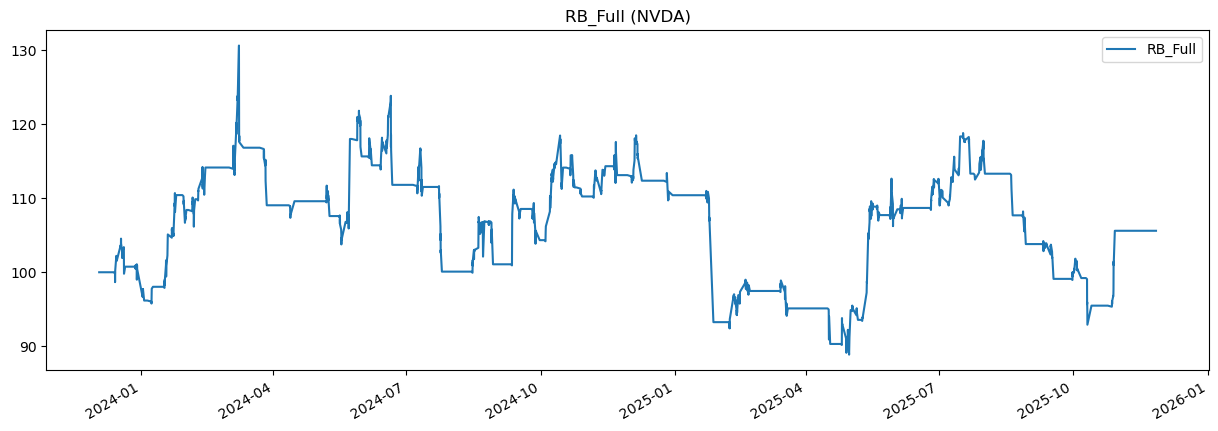

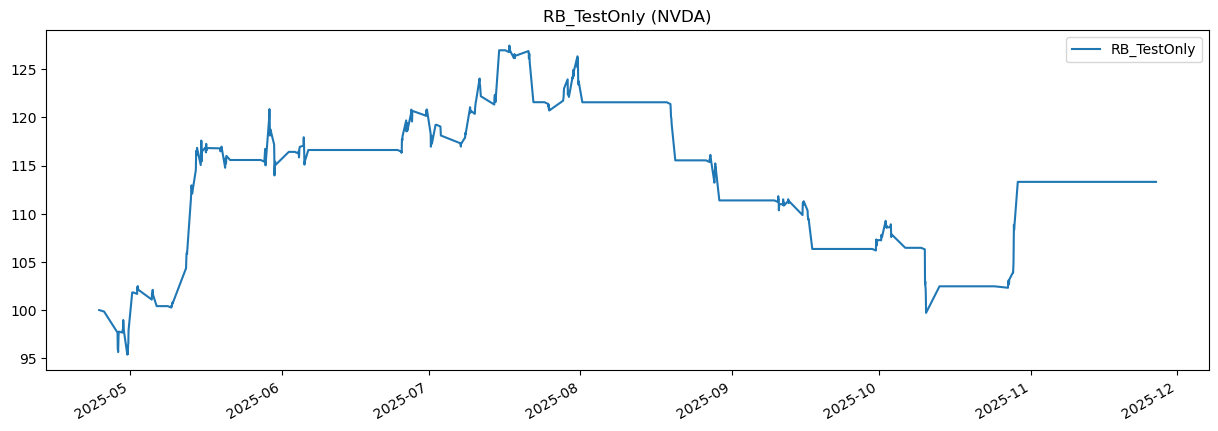

In [ ]:
# Strategy feature selection + robust signals + simple backtest (bt)
# Goal: defensible for coursework (testing/reproducibility), not "profit chasing".
# Principle: simple rules + avoid look-ahead + fees + train/test reliability check.

# Strategy with sentiment integration + improved risk management
# Improvements: sentiment filters, stop-loss to reduce drawdowns

# --- Parameters (simple to explain + easy to tune) ---
RSI_ENTRY = 55
RSI_EXIT = 45
ADX_MIN = 20
VPIN_MAX = 0.60
VPIN_FORCE_EXIT = 0.80
VOL_LOOKBACK = 252
VOL_MIN_PERIODS = 50
COST_RATE = 0.0015  # fees + slippage (0.15% per trade notional)

# Sentiment filters (NEW)
SENTIMENT_ENTRY_MIN = -0.3  # Don't enter if sentiment is very negative
SENTIMENT_EXIT_MIN = -0.5   # Exit if sentiment becomes very negative
USE_SENTIMENT = True        # Set False to disable sentiment filters

# Stop-loss (NEW - to reduce drawdowns)
STOP_LOSS_PCT = 0.15  # Exit if position loses more than 15% from entry price
USE_STOP_LOSS = True   # Set False to disable stop-loss

# 1) Small, interpretable feature set
FEATURES = [
    "close",
    "sma_21",
    "ema_21",
    "rsi_14",
    "adx_14",
    "yang_zhang_14",
    "VPIN",
    "regime",
]

# Drop warmup NaNs from rolling indicators
df_bt = df.copy()
df_bt = df_bt.dropna(subset=[c for c in FEATURES if c in df_bt.columns]).copy()

# 1.5) Load and merge sentiment data (if available)
if USE_SENTIMENT:
    SENTIMENT_CSV = r"C:\Uni\Year 3\flash-crash-sentinel\python_components\dataInCsv\articles_with_sentiment.csv"
    try:
        df_sent = pd.read_csv(SENTIMENT_CSV, low_memory=False)
        if 'ticker' in df_sent.columns:
            df_sent = df_sent[df_sent['ticker'].str.upper() == 'NVDA'].copy()
        if 'timestamp' in df_sent.columns and 'sentiment_score' in df_sent.columns:
            df_sent['timestamp'] = pd.to_datetime(df_sent['timestamp'], errors='coerce', utc=True)
            df_sent['timestamp'] = df_sent['timestamp'].dt.tz_localize(None)
            df_sent = df_sent.dropna(subset=['timestamp']).copy()
            df_sent['date'] = df_sent['timestamp'].dt.date
            daily_sent = df_sent.groupby('date')['sentiment_score'].mean().reset_index()
            daily_sent['timestamp'] = pd.to_datetime(daily_sent['date'])
            daily_sent = daily_sent.set_index('timestamp')
            # Merge with market data
            df_bt['date'] = df_bt.index.date
            df_bt['sentiment_score'] = df_bt['date'].map(
                dict(zip(daily_sent.index.date, daily_sent['sentiment_score']))
            ).ffill()
            df_bt = df_bt.drop(columns=['date'])
            print(f"✓ Sentiment data loaded: {len(daily_sent)} days")
        else:
            USE_SENTIMENT = False
            print("⚠ Sentiment columns not found, disabling sentiment filters")
    except Exception as e:
        USE_SENTIMENT = False
        print(f"⚠ Could not load sentiment data: {e}, disabling sentiment filters")
else:
    df_bt['sentiment_score'] = 0.0  # Default neutral if disabled

# 2) Entry/exit rules (trend + momentum + risk filters + sentiment)
trend_up = df_bt["close"] > df_bt["sma_21"]
momentum_up = df_bt["rsi_14"] >= RSI_ENTRY
trend_strong = df_bt["adx_14"] >= ADX_MIN

vpin_ok = df_bt["VPIN"].fillna(0.0) <= VPIN_MAX
regime_ok = df_bt["regime"].fillna(0).astype(int) != 2  # avoid crash regime

yz = df_bt["yang_zhang_14"].astype(float)
vol_ok = yz <= yz.rolling(VOL_LOOKBACK, min_periods=VOL_MIN_PERIODS).median()

# Sentiment filter for entry (NEW)
if USE_SENTIMENT:
    sentiment_ok_entry = df_bt["sentiment_score"].fillna(0.0) >= SENTIMENT_ENTRY_MIN
else:
    sentiment_ok_entry = True  # Always allow entry if sentiment is disabled

entry = trend_up & momentum_up & trend_strong & vpin_ok & regime_ok & vol_ok & sentiment_ok_entry

# Exit conditions
exit_ = (
    (df_bt["close"] < df_bt["sma_21"]) |
    (df_bt["rsi_14"] <= RSI_EXIT) |
    (df_bt["VPIN"] >= VPIN_FORCE_EXIT) |
    (df_bt["regime"].fillna(0).astype(int) == 2)
)

# Sentiment filter for exit (NEW)
if USE_SENTIMENT:
    exit_ = exit_ | (df_bt["sentiment_score"].fillna(0.0) < SENTIMENT_EXIT_MIN)

# 3) Position state machine with stop-loss tracking
pos = 0
entry_price = None
positions = []
stop_loss_triggered = []

for i, (e, x, price) in enumerate(zip(entry.values, exit_.values, df_bt["close"].values)):
    # Check stop-loss if in position (NEW)
    stop_loss_exit = False
    if USE_STOP_LOSS and pos == 1 and entry_price is not None:
        pct_loss = (price - entry_price) / entry_price
        if pct_loss <= -STOP_LOSS_PCT:
            stop_loss_exit = True
    
    if pos == 0 and bool(e):
        pos = 1
        entry_price = price
    elif pos == 1 and (bool(x) or stop_loss_exit):
        pos = 0
        entry_price = None
    
    positions.append(pos)
    stop_loss_triggered.append(1 if stop_loss_exit else 0)

positions = pd.Series(positions, index=df_bt.index, name="NVDA")
stop_loss_exits = pd.Series(stop_loss_triggered, index=df_bt.index)

# IMPORTANT: avoid look-ahead bias. Execute the signal on the *next* bar.
positions = positions.shift(1).fillna(0).astype(int)

# Trade counts (helps interpret fees and stop-loss usage)
entries = int((positions.diff() == 1).sum())
exits = int((positions.diff() == -1).sum())
stop_loss_count = int(stop_loss_exits.sum())
print(f"Trades: entries={entries}, exits={exits}, stop-losses={stop_loss_count} ({(stop_loss_count/exits*100) if exits > 0 else 0:.1f}% of exits)")

# 4) Build bt inputs
prices = df_bt["close"].rename("NVDA").to_frame()
select = (positions == 1).to_frame()


def run_bt(prices_df: pd.DataFrame, select_df: pd.DataFrame, name: str):
    strat = bt.Strategy(
        name,
        [
            bt.algos.RunDaily(),
            bt.algos.SelectWhere(select_df),
            bt.algos.WeighEqually(),
            bt.algos.Rebalance(),
        ],
    )
    test = bt.Backtest(strat, prices_df, commissions=lambda q, p: abs(q) * p * COST_RATE)
    return bt.run(test)


# 5) Full backtest + simple train/test split (reliability check)
split_idx = int(len(df_bt) * 0.70)
split_ts = df_bt.index[split_idx]
print(f"Train/Test split timestamp: {split_ts} (70/30)")
print(f"Approx trades: entries={entries}, exits={exits}; cost_rate={COST_RATE}")

res_full = run_bt(prices, select, "RB_Full")

prices_test = prices.loc[split_ts:]
select_test = select.loc[split_ts:]
res_test = run_bt(prices_test, select_test, "RB_TestOnly")

print("\n=== FULL PERIOD ===")
res_full.display()
res_full.plot(title="RB_Full (NVDA)")

print("\n=== TEST-ONLY (OUT-OF-SAMPLE) ===")
res_test.display()
res_test.plot(title="RB_TestOnly (NVDA)")

print("\nPosition stats:")
print(
    pd.DataFrame(
        {
            "in_position": positions.value_counts().sort_index(),
            "pct_in_position": positions.value_counts(normalize=True).sort_index(),
        }
    )
)
